In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clinical = pd.read_csv('clinical.tsv', sep='\t')
exposure = pd.read_csv('exposure.tsv', sep='\t')

print("Clinical shape:", clinical.shape)
print("Exposure shape:", exposure.shape)
print("\nExposure columns:", exposure.columns.tolist())

Clinical shape: (2466, 201)
Exposure shape: (522, 35)

Exposure columns: ['project.project_id', 'cases.case_id', 'cases.submitter_id', 'exposures.age_at_last_exposure', 'exposures.age_at_onset', 'exposures.alcohol_days_per_week', 'exposures.alcohol_drinks_per_day', 'exposures.alcohol_frequency', 'exposures.alcohol_history', 'exposures.alcohol_intensity', 'exposures.alcohol_type', 'exposures.asbestos_exposure_type', 'exposures.chemical_exposure_type', 'exposures.cigarettes_per_day', 'exposures.environmental_tobacco_smoke_exposure', 'exposures.exposure_duration', 'exposures.exposure_duration_hrs_per_day', 'exposures.exposure_duration_years', 'exposures.exposure_id', 'exposures.exposure_source', 'exposures.exposure_type', 'exposures.occupation_duration_years', 'exposures.occupation_type', 'exposures.pack_years_smoked', 'exposures.parent_with_radiation_exposure', 'exposures.secondhand_smoke_as_child', 'exposures.smoking_frequency', 'exposures.submitter_id', 'exposures.time_between_waking_a

In [2]:
# Merge the two files on case ID
merged = pd.merge(exposure, clinical, on='cases.case_id', how='inner')

# Check smoking status categories
print(merged['exposures.tobacco_smoking_status'].value_counts())

exposures.tobacco_smoking_status
Current Reformed Smoker for < or = 15 yrs          841
Current Reformed Smoker for > 15 yrs               623
Current Smoker                                     490
Lifelong Non-Smoker                                355
Not Reported                                        76
Current Reformed Smoker, Duration Not Specified     11
Unknown                                              7
Name: count, dtype: int64


In [3]:
# Clean up smoking status into 3 simple groups
def categorize_smoking(status):
    if status == 'Lifelong Non-Smoker':
        return 'Never Smoker'
    elif status in ['Current Smoker']:
        return 'Current Smoker'
    elif 'Reformed' in str(status):
        return 'Former Smoker'
    else:
        return None

merged['smoking_group'] = merged['exposures.tobacco_smoking_status'].apply(categorize_smoking)

# Drop unknown/not reported
df = merged[merged['smoking_group'].notna()].copy()

print(df['smoking_group'].value_counts())
print("\nTotal patients:", len(df))

smoking_group
Former Smoker     1475
Current Smoker     490
Never Smoker       355
Name: count, dtype: int64

Total patients: 2320


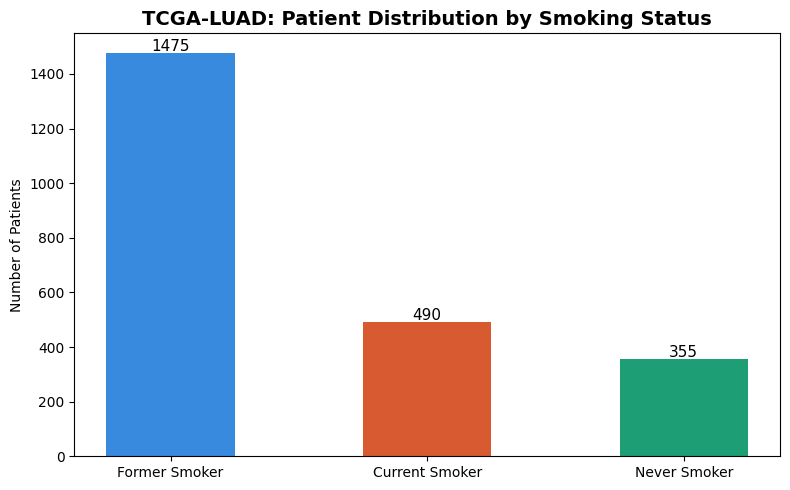

Gender column found: demographic.gender


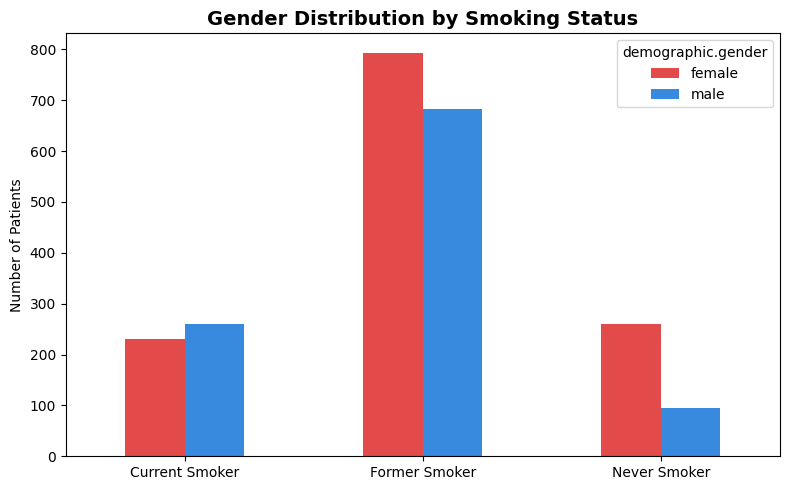

Age column found: diagnoses.age_at_diagnosis


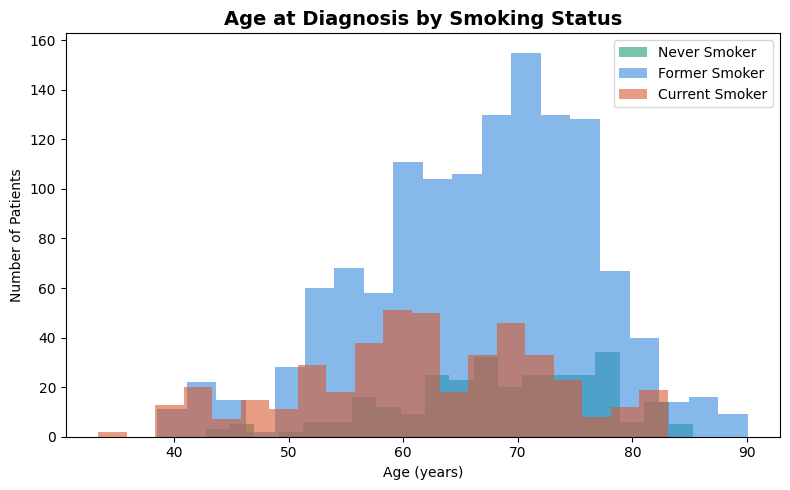

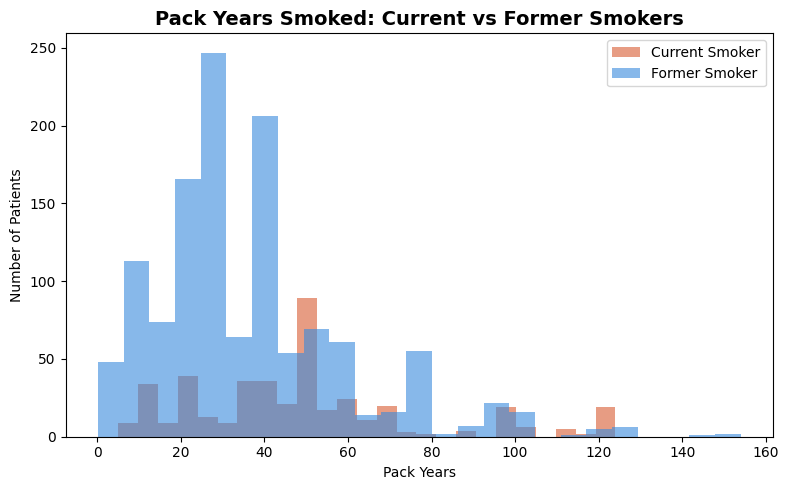


All charts saved.


In [4]:
# Set up clean style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
colors = {'Never Smoker': '#1D9E75', 'Former Smoker': '#378ADD', 'Current Smoker': '#D85A30'}

# --- Chart 1: Patient distribution by smoking group ---
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['smoking_group'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[colors[x] for x in counts.index], width=0.5)
ax.set_title('TCGA-LUAD: Patient Distribution by Smoking Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('chart1_distribution.png', dpi=150)
plt.show()

# --- Chart 2: Gender breakdown by smoking group ---
gender_col = [c for c in df.columns if 'gender' in c.lower() or 'sex' in c.lower()][0]
print("Gender column found:", gender_col)
gender_data = df.groupby(['smoking_group', gender_col]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
gender_data.plot(kind='bar', ax=ax, color=['#E24B4A', '#378ADD'], width=0.5)
ax.set_title('Gender Distribution by Smoking Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_gender.png', dpi=150)
plt.show()

# --- Chart 3: Age at diagnosis by smoking group ---
age_col = [c for c in df.columns if 'age_at_diagnosis' in c.lower()][0]
print("Age column found:", age_col)
df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
df['age_years'] = df[age_col] / 365

fig, ax = plt.subplots(figsize=(8, 5))
for group, color in colors.items():
    subset = df[df['smoking_group'] == group]['age_years'].dropna()
    ax.hist(subset, bins=20, alpha=0.6, label=group, color=color)
ax.set_title('Age at Diagnosis by Smoking Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.legend()
plt.tight_layout()
plt.savefig('chart3_age.png', dpi=150)
plt.show()

# --- Chart 4: Pack years smoked ---
df['pack_years'] = pd.to_numeric(df['exposures.pack_years_smoked'], errors='coerce')
fig, ax = plt.subplots(figsize=(8, 5))
smokers_only = df[df['smoking_group'] != 'Never Smoker']
for group in ['Current Smoker', 'Former Smoker']:
    subset = smokers_only[smokers_only['smoking_group'] == group]['pack_years'].dropna()
    ax.hist(subset, bins=25, alpha=0.6, label=group, color=colors[group])
ax.set_title('Pack Years Smoked: Current vs Former Smokers', fontsize=14, fontweight='bold')
ax.set_xlabel('Pack Years')
ax.set_ylabel('Number of Patients')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_packyears.png', dpi=150)
plt.show()

print("\nAll charts saved.")

In [5]:
# Summary stats table
summary = df.groupby('smoking_group').agg(
    count=('smoking_group', 'count'),
    avg_age=('age_years', 'mean'),
    avg_pack_years=('pack_years', 'mean')
).round(1)

print(summary)

                count  avg_age  avg_pack_years
smoking_group                                 
Current Smoker    490     61.8            48.8
Former Smoker    1475     66.7            36.4
Never Smoker      355     68.5             NaN


In [6]:
vital_col = [c for c in df.columns if 'vital_status' in c.lower()][0]
print("Vital status column:", vital_col)
print(df[vital_col].value_counts())

survival = df.groupby(['smoking_group', vital_col]).size().unstack(fill_value=0)
print("\n", survival)

Vital status column: demographic.vital_status
demographic.vital_status
Alive    1303
Dead     1017
Name: count, dtype: int64

 demographic.vital_status  Alive  Dead
smoking_group                        
Current Smoker              278   212
Former Smoker               830   645
Never Smoker                195   160


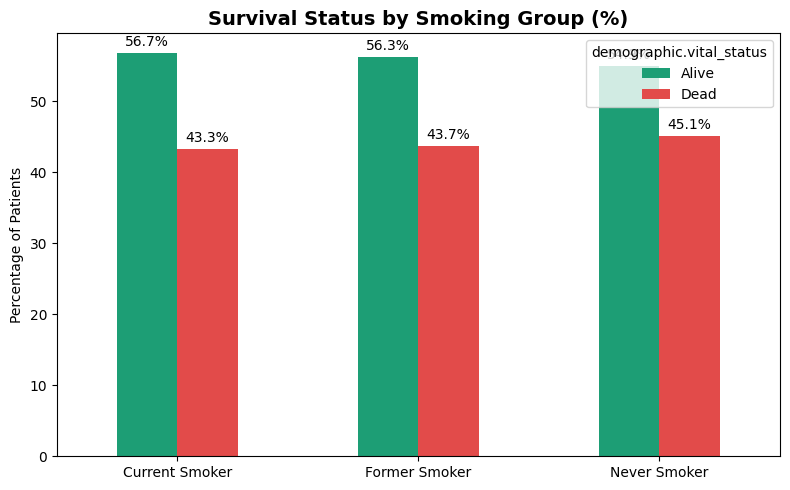


Survival rates (%):
demographic.vital_status  Alive  Dead
smoking_group                        
Current Smoker             56.7  43.3
Former Smoker              56.3  43.7
Never Smoker               54.9  45.1


In [7]:
# Chart 5: Survival outcomes by smoking group
fig, ax = plt.subplots(figsize=(8, 5))

survival_pct = survival.div(survival.sum(axis=1), axis=0) * 100

survival_pct.plot(kind='bar', ax=ax, color=['#1D9E75', '#E24B4A'], width=0.5)
ax.set_title('Survival Status by Smoking Group (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of Patients')
ax.set_xlabel('')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig('chart5_survival.png', dpi=150)
plt.show()

# Print the percentages cleanly
print("\nSurvival rates (%):")
print(survival_pct.round(1))

In [9]:
readme = """# TCGA-LUAD Lung Cancer Clinical Analysis
## Exploratory analysis of smoking status and clinical outcomes in lung adenocarcinoma

### Background
Lung adenocarcinoma (LUAD) is uniquely prevalent in non-smokers compared to other lung cancer subtypes.
This analysis explores whether non-smoker LUAD patients show distinct clinical patterns —
motivated by ongoing metabolomics research at Rajiv Gandhi Centre for Biotechnology (RGCB)
investigating why non-smokers develop lung cancer.

### Dataset
- Source: The Cancer Genome Atlas (TCGA-LUAD)
- Portal: https://portal.gdc.cancer.gov
- Patients analysed: 2,320
- Files used: clinical.tsv, exposure.tsv

### Patient Groups
| Smoking Status | N | Avg Age at Diagnosis | Avg Pack Years |
|---|---|---|---|
| Never Smoker | 355 | 68.5 years | — |
| Former Smoker | 1,475 | 66.7 years | 36.4 |
| Current Smoker | 490 | 61.8 years | 48.8 |

### Key Findings
1. **Age at diagnosis:** Never smokers are diagnosed 6.7 years later than current smokers (68.5 vs 61.8 years), suggesting a slower or distinct biological mechanism in non-smoker lung cancer
2. **Survival rates:** Surprisingly similar across all groups (~56% alive), indicating smoking status alone does not predict survival in LUAD — pointing toward other biological drivers such as metabolic differences
3. **Gender patterns:** See chart — non-smoker LUAD shows higher female prevalence, consistent with published literature
4. **Pack years:** Current smokers show higher pack year burden (48.8) than former smokers (36.4), expected given former smokers had time to quit

### Biological Relevance
The similar survival rates despite vastly different smoking exposures suggest non-smoker LUAD
may be driven by distinct molecular mechanisms — potentially metabolic in origin.
This aligns with RGCB research into the metabolomes of lung cancer patients.

### Charts Generated
- chart1_distribution.png — patient counts by smoking group
- chart2_gender.png — gender breakdown by smoking group
- chart3_age.png — age at diagnosis distributions
- chart4_packyears.png — pack years in smokers
- chart5_survival.png — survival outcomes by group

### Tools Used
Python — pandas, matplotlib, seaborn
Google Colab

### Author
Diya Jacson — Biotechnology, VIT Vellore
Conducted during internship at Rajiv Gandhi Centre for Biotechnology, Thiruvananthapuram
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README saved.")

README saved.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')